In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import pinv, qr
from scipy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D
import warnings
from scipy import stats
from scipy.stats import bootstrap

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 26})


In [2]:
def jac_reservoir(r, Wo, Wi, Wh, b):
    A = Wh + Wi @ Wo              # (h x h)
    Ar = A @ r + b                # (h x 1)
    sech2 = 1 / np.cosh(Ar)**2    # (h x 1)
    jac = A * sech2               # Broadcast sech² element-wise across rows of A
    return jac


def bootstrp(nboot, func, data):
    """Bootstrap resampling equivalent to MATLAB bootstrp"""
    n = len(data)
    results = []
    for _ in range(nboot):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        sample = data[indices]
        results.append(func(sample))
    return np.array(results)

def bootci(nboot, func, data, alpha=0.05):
    """Bootstrap confidence intervals equivalent to MATLAB bootci"""
    boot_stats = bootstrp(nboot, func, data)
    if boot_stats.ndim == 1:
        boot_stats = boot_stats.reshape(-1, 1)
    
    ci_lower = np.percentile(boot_stats, 100 * alpha/2, axis=0)
    ci_upper = np.percentile(boot_stats, 100 * (1 - alpha/2), axis=0)
    return np.vstack([ci_lower, ci_upper])

In [4]:
def standard_map(K, theta0, p0, T, tT=0):
    N = T + tT
    theta = np.empty(N + 1)
    p = np.empty(N + 1)
    theta[0] = theta0 % (2 * np.pi)
    p[0] = p0

    for n in range(N):
        p[n+1] = p[n] + K * np.sin(theta[n])
        theta[n+1] = (theta[n] + p[n+1]) % (2 * np.pi)

    return np.array([theta[tT+1:], p[tT+1:]])  # discard transient

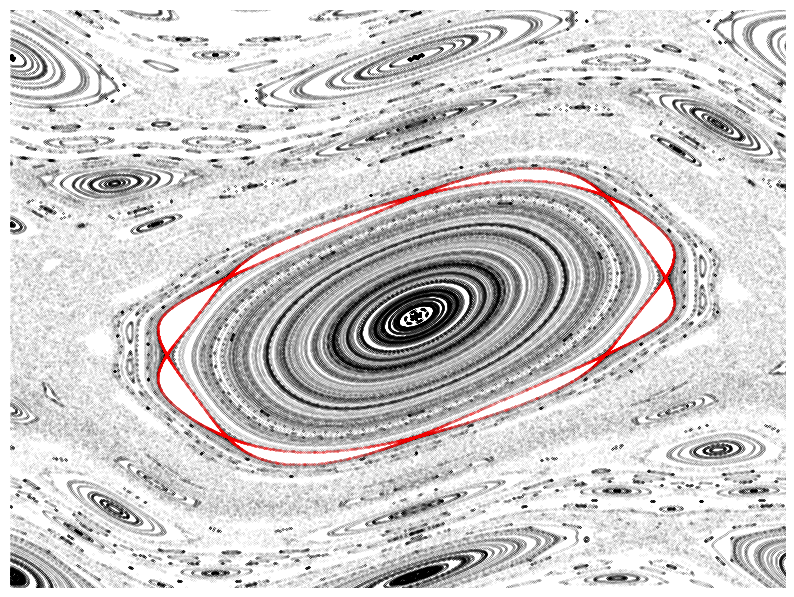

In [5]:
K = 1.
plt.figure(figsize=[10,7.5])
np.random.seed(0)
p0s = np.random.rand(700)*np.pi*4#10
for p0 in p0s:
    theta0 = np.pi
    T = 1000
    tT = 100
    y = standard_map(K, theta0, p0 , T, tT)
    plt.plot(y[0],y[1],'.',c='k',ms=.1)

p0 = 4.8210739
theta0 = np.pi
T = 20000
tT = 100
y = standard_map(K, theta0, p0 , T, tT)
plt.plot(y[0],y[1],'.',c='r',ms=.1)
plt.plot(y[0],y[1],'.',c='r',ms=.1)
plt.xlim([0,6])
plt.ylim([3,10])
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()

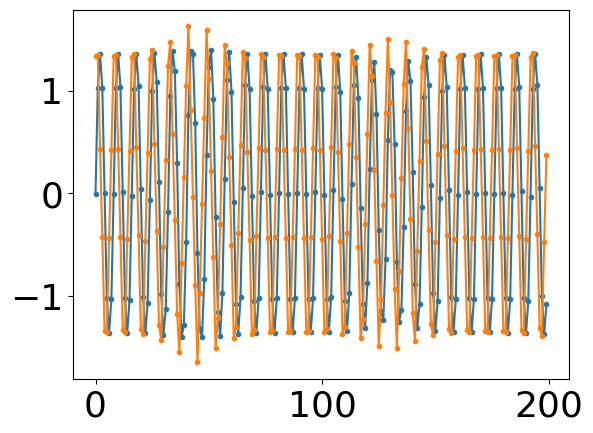

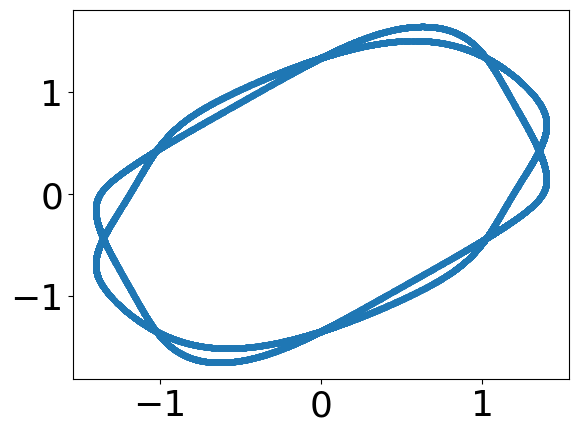

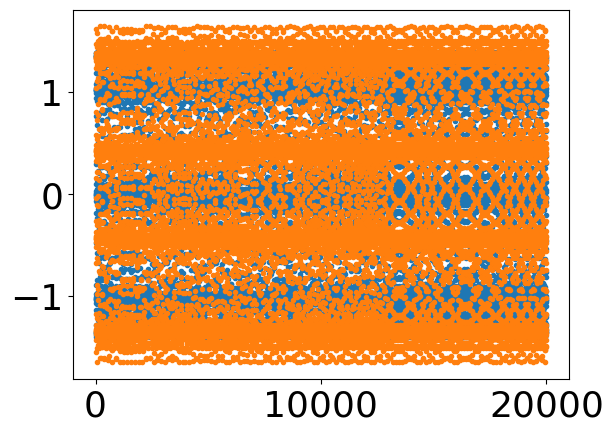

In [6]:
# Parameters
K = 1.
theta0, p0 = np.pi, 4.82#10739

T = 10**5
tT = 100

y = standard_map(K, theta0, p0 , T, tT)

U = (y.T - np.mean(y,axis=1)) / np.std(y,axis=1)
# U = U.T#reshape(-1, 1)

plt.figure()
plt.plot(U[:200, 0],'.-')
plt.plot(U[:200, 1],'.-')
plt.show()

plt.figure()
plt.plot(U[:, 0],U[:, 1],'.')
# plt.plot(U[:20000, 1],'.')
plt.show()

plt.figure()
plt.plot(U[:20000, 0],'.')
plt.plot(U[:20000, 1],'.')
plt.show()

strain = U[:int(np.floor(U.shape[0]/2)), :1]
stest = U[int(np.floor(U.shape[0]/2)):, :1]
dim = strain.shape[-1]
dt = 1

0.0092


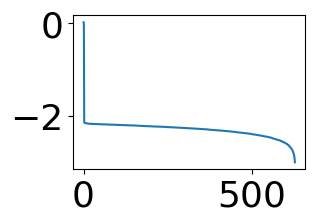

0.021319999999999895
0.06796000000000002
0.03402000000000001
0.010159999999999995


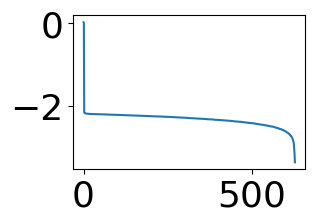

0.015560000000000018
0.04424
0.07096
0.01774000000000009
0.010919999999999992


In [ ]:
lyapus = []

seed = 1
np.random.seed(seed)
for loop in range(30):
    test = 1
    while test>0.012:
        h = 630
        kh = 1e-05
        ki = 1.
        kb = ki

        Wh = kh * np.random.randn(h, h)  # hidden-to-hidden
        Wi = ki * np.random.randn(h, dim)  # input-to-hidden
        b = kb * np.random.randn(h, 1)  # hidden bias

        trainnum = strain.shape[0]
        hiddens = np.zeros((h, trainnum))
        rs = -kh + (2*kh) * np.random.rand(h, 1)

        for i in range(trainnum):
            rs = np.tanh(Wh @ rs + Wi @ strain[i, :].reshape(-1, 1) + b)
            hiddens[:, i] = rs.flatten()

        convnum = 1000 # step when a hidden state converges
        Wo = strain[convnum:, :].T @ pinv(hiddens[:, convnum-1:-1])

        # %% estimate lyapunov exponents
        prednum = 10**4 # int(T/dt/2)
        preds_lyap = np.zeros((prednum, dim))

        rss = np.zeros((prednum, h))
        idx = 100
        rs = -np.sqrt(kh) + (2*np.sqrt(kh)) * np.random.rand(h, 1)

        for i in range(convnum):
            rs = np.tanh(Wh @ rs + Wi @ strain[idx + i, :].reshape(-1, 1) + b)

        pred = Wo @ rs
        for i in range(prednum):
            rs = np.tanh(Wh @ rs + Wi @ pred + b)
            pred = Wo @ rs
            preds_lyap[i, :] = pred.flatten()[:dim]
            rss[i, :] = rs.flatten()

        test = stats.ks_2samp(strain.reshape([-1]), preds_lyap.T[0]).statistic
        print(test)

    # %% Forward transient
    n0 = int(15/dt) #int(15/dt)  # steps for transient
    k = 10  # sampling step
    G = np.random.rand(h, h)
    G, _ = qr(G)

    for i in range(n0//k):
        for j in range(k):
            J = jac_reservoir(rss[k*i + j, :].reshape(-1, 1), Wo, Wi, Wh, b)
            G = J @ G
        G, R = qr(G)  # QR decomposition

    # Forward dynamics
    t0 = n0  # backward transient
    t = prednum - n0 - t0  # int(T/2/dt) - n0 - t0
    # t = int(T/10/dt) - n0 - t0
    Glist = np.zeros((h, h, (t + t0)//k - 1))
    Rlist = np.zeros((h, h, (t + t0)//k - 1))
    Glist[:, :, 0] = G
    Rlist[:, :, 0] = R

    for i in range((t + t0)//k - 1):
        for j in range(k):
            J = jac_reservoir(rss[k*i + j + n0, :].reshape(-1, 1), Wo, Wi, Wh, b)
            G = J @ G
        G, R = qr(G)  # QR decomposition
        Glist[:, :, i] = G
        Rlist[:, :, i] = R

    # %%
    lyapu_all = np.zeros(h)
    for i in range((t + t0)//k - 1):
        for j in range(h):
            lyapu_all[j] += np.log(np.linalg.norm(Rlist[j, j, i]))

    lyapu_all = lyapu_all / (t + t0) / dt
    plt.figure(figsize=[3,2])
    plt.plot(np.sort(lyapu_all)[::-1])
    plt.show()
    lyapus.append(np.sort(lyapu_all)[::-1])


In [25]:
lyapus = np.array(lyapus)

med = np.median(lyapus, axis=0)

# Bootstrap 95% CI for median at each index
err_low = np.zeros(lyapus.shape[1])
err_high = np.zeros(lyapus.shape[1])

for i in range(lyapus.shape[1]):
    res = bootstrap(
        (lyapus[:, i],), 
        np.median, 
        confidence_level=0.95,
        n_resamples=5000,
        method='percentile',
        vectorized=False
    )
    err_low[i] = med[i] - res.confidence_interval.low
    err_high[i] = res.confidence_interval.high - med[i]

<ErrorbarContainer object of 3 artists>

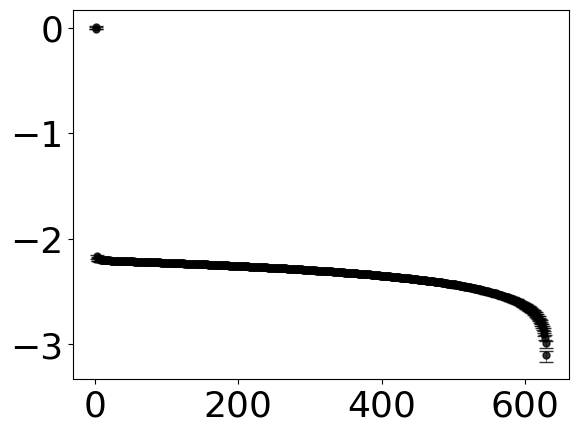

In [26]:
idx = np.linspace(1, h, h)
plt.errorbar(idx, med, yerr=[err_low, err_high],
             fmt='k.', ms=10, capsize=5, elinewidth=.5, alpha=0.8)

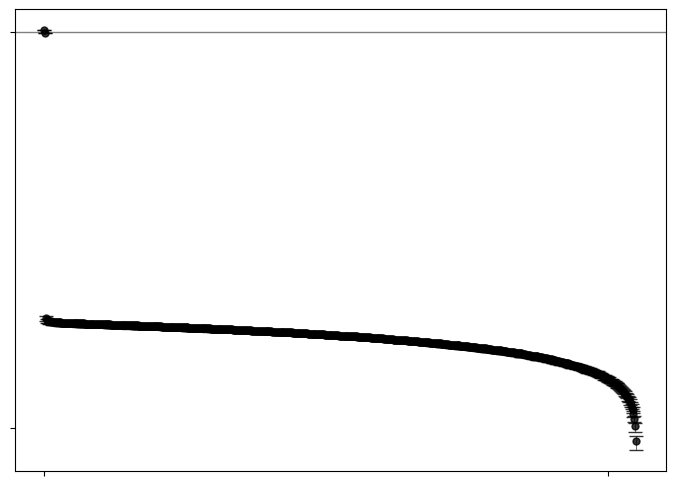

In [27]:
idx = np.linspace(1, h, h)
plt.figure(figsize=(8.4,6), facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')                      # transparent axes background


# Use asymmetric error bars
plt.errorbar(idx, med, yerr=[err_low, err_high],
             fmt='k.', ms=10, capsize=5, elinewidth=.5, alpha=0.8)

plt.axhline(0, c='k', ls='-', lw=1., alpha=.5, label='$\log_e 2$')
plt.xticks([1, 600], ['', ''])   # hide default label for 100
plt.yticks([0,-3], ['', ''])
plt.show()


In [29]:
def standard_map_jacobian(theta, K):
    dfdx = np.array([
        [1 + K * np.cos(theta), 1],
        [K * np.cos(theta),     1]
    ])
    return dfdx

def estimate_lyapunov_spectrum(K, theta0, p0, T, renorm_interval=1):
    # Initialize trajectory
    theta = theta0 % (2 * np.pi)
    p = p0

    # Initialize orthonormal basis vectors (2D identity matrix)
    Q = np.eye(2)
    log_stretch = np.zeros(2)

    ps = []

    for t in range(T):
        # Update the base trajectory
        p = p + K * np.sin(theta)
        ps.append(p)
        theta = (theta + p) % (2 * np.pi)
        
        # Evolve tangent vectors
        J = standard_map_jacobian(theta, K)
        Q = J @ Q

        # QR decomposition (Gram-Schmidt orthonormalization)
        if (t + 1) % renorm_interval == 0:
            Q, R = np.linalg.qr(Q)
            log_stretch += np.log(np.abs(np.diag(R)))
    plt.plot(ps)
    plt.show()
    lyapunov_exponents = log_stretch / T
    return np.sort(lyapunov_exponents)[::-1]  # Return [λ1, λ2]


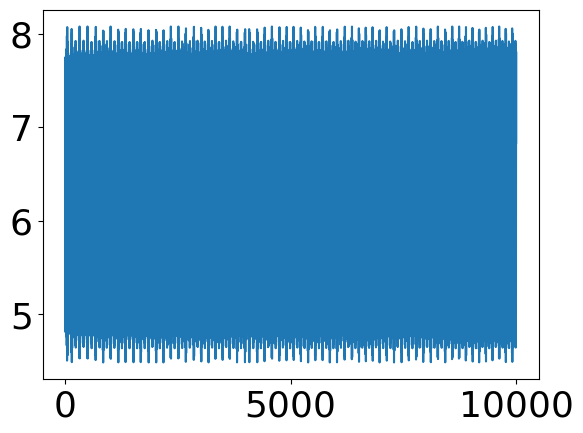

Lyapunov exponents: [ 0.01090878 -0.01090878]


In [32]:
T = prednum  # More iterations for better accuracy

lambdas = estimate_lyapunov_spectrum(K, theta0, p0, 1*10**4,renorm_interval=10**1)
print("Lyapunov exponents:", lambdas)

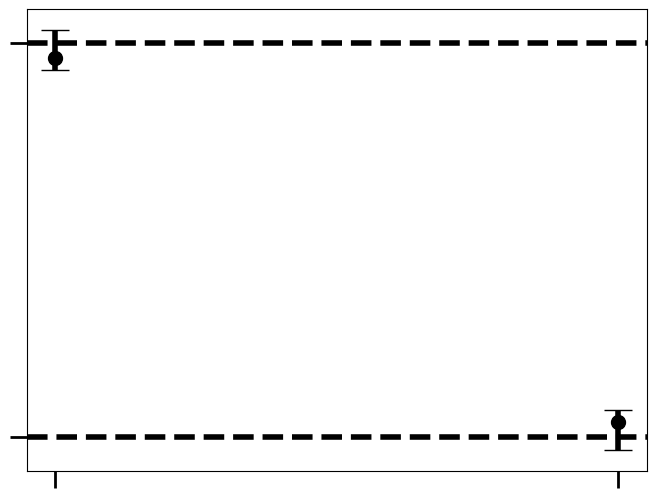

In [33]:
idx = np.linspace(1, h, h)
plt.figure(figsize=(4*2,3*2), facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none')                      # transparent axes background


# Use asymmetric error bars
plt.errorbar(idx[:2], med[:2], yerr=[err_low[:2], err_high[:2]],
             fmt='k.', ms=10*2, capsize=10, elinewidth=2*2, alpha=1)

plt.axhline(lambdas[0], c='k', ls='--', lw=2*2, label='$\log_e 2$')
plt.axhline(lambdas[1], c='k', ls='--', lw=2*2, label='$\log_e 2$')

ax.tick_params(axis='both', which='major', length=12, width=2)
ax.tick_params(axis='both', which='minor', length=8, width=1.5)

plt.xticks([1, 2], ['', ''])   # hide default label for 100
plt.yticks(lambdas, ['', ''])

plt.show()


In [3]:
lyaptimemtx = np.load('../results_data/vpt_sta_20251111_01.npy', allow_pickle=True)
distmtx = np.load('../results_data/dist_sta_20251111_01.npy', allow_pickle=True)
khlist = np.load('../results_data/khlist_sta_20251111_01.npy', allow_pickle=True)
kilist = np.load('../results_data/kilist_sta_20251111_01.npy', allow_pickle=True)

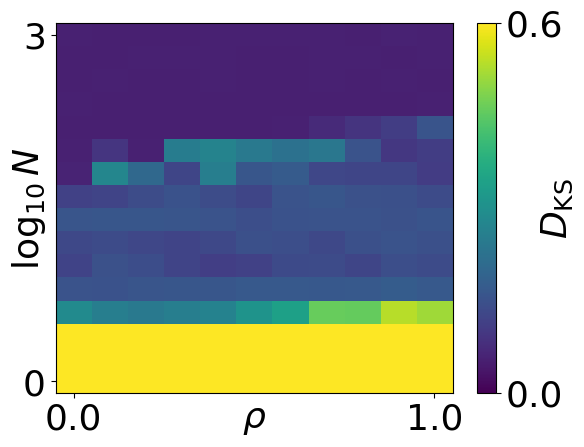

In [4]:
im = distmtx
plt.figure()
img = plt.imshow(im, aspect='auto',vmin=0,vmax=.6)
cbar = plt.colorbar(img)

# --- Customize colorbar ticks ---
cbar.set_ticks([0, .6])             # set custom tick positions

# --- Move colorbar label ---
cbar.set_label('$D_\mathrm{KS}$', labelpad=-17)   # adjust padding

plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)

plt.xticks([0, len(khlist) - 1], [khlist[0], "{:.1f}".format(khlist[-1])])
plt.yticks([0, len(kilist) - 1], ["{:.0f}".format(np.log10(kilist[0])), "{:.0f}".format(np.log10(kilist[-1]))])
plt.gca().invert_yaxis()
plt.show()


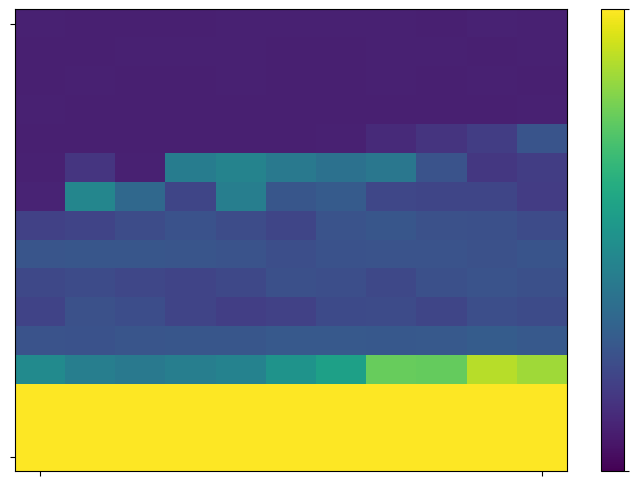

In [5]:
im = distmtx
plt.figure(figsize=(8.9,6),facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none') 
img = plt.imshow(im, aspect='auto', vmin=0, vmax=.6)
cbar = plt.colorbar(img)

# --- Keep only min/max ticks, but remove labels on colorbar ---
cbar.set_ticks([0, .6])          # keep ticks at min and max
cbar.set_ticklabels([])         # remove tick labels
cbar.set_label('')              # remove colorbar label

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but no labels ---
plt.xticks([0, len(khlist) - 1], ['', ''])
plt.yticks([0, len(kilist) - 1], ['', ''])

plt.gca().invert_yaxis()

plt.show()


In [6]:
lyaptimemtx = np.load('../results_data/vpt_sta_part_20251111_00.npy', allow_pickle=True)
distmtx = np.load('../results_data/dist_sta_part_20251111_00.npy', allow_pickle=True)
khlist = np.load('../results_data/khlist_sta_part_20251111_00.npy', allow_pickle=True)
kilist = np.load('../results_data/kilist_sta_part_20251111_00.npy', allow_pickle=True)

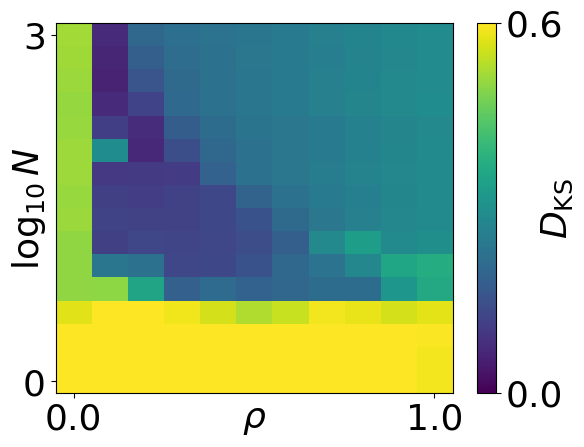

In [7]:
im = distmtx
plt.figure()
img = plt.imshow(im, aspect='auto',vmin=0,vmax=.6)
cbar = plt.colorbar(img)

# --- Customize colorbar ticks ---
cbar.set_ticks([0, .6])             # set custom tick positions

# --- Move colorbar label ---
cbar.set_label('$D_\mathrm{KS}$', labelpad=-17)   # adjust padding
plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)

plt.xticks([0, len(khlist) - 1], [khlist[0], "{:.1f}".format(khlist[-1])])
plt.yticks([0, len(kilist) - 1], ["{:.0f}".format(np.log10(kilist[0])), "{:.0f}".format(np.log10(kilist[-1]))])
plt.gca().invert_yaxis()

plt.show()


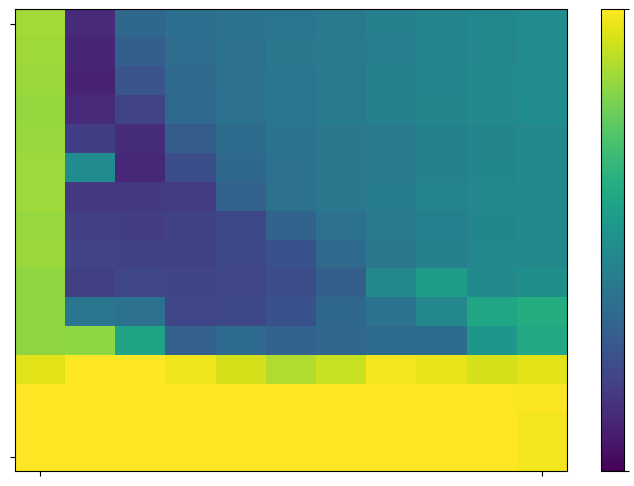

In [8]:
im = distmtx
plt.figure(figsize=(8.9,6),facecolor='none')   # transparent figure background
ax = plt.gca()
ax.set_facecolor('none') 
img = plt.imshow(im, aspect='auto', vmin=0, vmax=.6)
cbar = plt.colorbar(img)

# --- Keep only min/max ticks, but remove labels on colorbar ---
cbar.set_ticks([0, .6])          # keep ticks at min and max
cbar.set_ticklabels([])         # remove tick labels
cbar.set_label('')              # remove colorbar label

# --- Remove axis labels ---
plt.xlabel('')
plt.ylabel('')

# --- Keep only min/max ticks, but no labels ---
plt.xticks([0, len(khlist) - 1], ['', ''])
plt.yticks([0, len(kilist) - 1], ['', ''])

plt.gca().invert_yaxis()

plt.show()
